### **Problem 1**
Take a look at our lecture notes (lecture 04) where we built a matplotlib figure of a lattice of HEU and LEU pins. Using your knowledge learned from these examples, build a diagram of a TRIGA-like reactor core in matplotlib. The TRIGA-like model can constructed as a grouping of three different pins: fueled pins where the fuel has r=3.63cm, and the outer radius of the pin is r=3.73cm. Assume there is no air gap between the fuel and the cladding.  Control rods can be modeled as an additional pin filled with B4C. Assume the radius of b4c fill is r=3.58cm and the outer radius of the pin is 3.73cm. The final pin is a solid graphite slug with an outer radius of r=3.73cm. TRIGA cores are constructed of concentric rings of pins. In a ring, assume each pin is equally spaced in the ring. Rings are spaced 8cm apart from one another. The outermost ring is all graphite pins. The control rods all exist in ring 3 and are equally spaced from each other. All other pins are fuel. State any assumptions you make clearly.

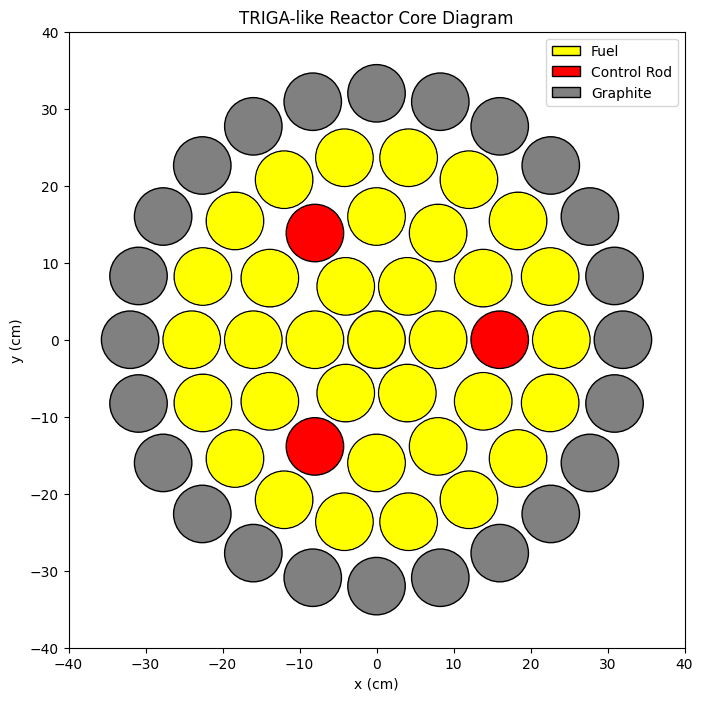

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Pin definitions
pin_outer_radius = 3.73  # cm, all pins
fuel_radius = 3.63       # cm
b4c_radius = 3.58        # cm

# Ring definitions
rings = [
    {"radius": 0, "pins": 1},    # Center pin
    {"radius": 8, "pins": 6},
    {"radius": 16, "pins": 12},
    {"radius": 24, "pins": 18},
    {"radius": 32, "pins": 24}
]

# Control rods
control_rod_ring = 2  # ring 3
control_rods = 3      # number of control rods in ring 3

fig, ax = plt.subplots(figsize=(8, 8))

# Plot pins
pin_centers = []
for i, ring in enumerate(rings):
    n_pins = ring["pins"]
    r = ring["radius"]
    if n_pins == 1:
        # Center pin
        pin_centers.append((0, 0))
        # Assume center pin is fuel
        circle = plt.Circle((0, 0), pin_outer_radius, color='yellow', ec='k', lw=1, label='Fuel' if i == 0 else "")
        ax.add_patch(circle)
        plt.Circle((0, 0), fuel_radius, color='yellow', ec='none')
    else:
        angles = np.linspace(0, 2 * np.pi, n_pins, endpoint=False)
        for j, theta in enumerate(angles):
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            pin_centers.append((x, y))
            # Determine pin type
            if i == len(rings) - 1:
                # Outermost ring: graphite
                circle = plt.Circle((x, y), pin_outer_radius, color='gray', ec='k', lw=1, label='Graphite' if (i == len(rings) - 1 and j == 0) else "")
                ax.add_patch(circle)
            elif i == control_rod_ring:
                # Ring with control rods
                if j % (n_pins // control_rods) == 0:
                    # Place control rods equally spaced
                    circle = plt.Circle((x, y), pin_outer_radius, color='red', ec='k', lw=1, label='Control Rod' if j == 0 else "")
                    ax.add_patch(circle)
                    inner = plt.Circle((x, y), b4c_radius, color='red', ec='none')
                    ax.add_patch(inner)
                else:
                    # Fuel pins
                    circle = plt.Circle((x, y), pin_outer_radius, color='yellow', ec='k', lw=1, label='Fuel' if (i == 1 and j == 0) else "")
                    ax.add_patch(circle)
                    inner = plt.Circle((x, y), fuel_radius, color='yellow', ec='none')
                    ax.add_patch(inner)
            else:
                # Fuel pins
                circle = plt.Circle((x, y), pin_outer_radius, color='yellow', ec='k', lw=1, label='Fuel' if (i == 1 and j == 0) else "")
                ax.add_patch(circle)
                inner = plt.Circle((x, y), fuel_radius, color='yellow', ec='none')
                ax.add_patch(inner)

# Legend (avoid duplicate labels)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.set_aspect('equal')
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_title('TRIGA-like Reactor Core Diagram')

plt.show()

# Assumptions:
# - All pins are circular and have the same outer radius.
# - No air gap between fuel/control rod and cladding.
# - Control rods are placed equally spaced in only in ring 3.
# - All pins not specified as control rods or graphite are fuel.

### **Problem 5.1**
Write a Python dictionary that contains the key:value pairs that have for a key the name of the common subatomic particles (i.e., proton, neutron, and electron) and the value the mass of the particle in kilograms.

In [5]:
#simple dictionary
subatomic_masses = {"proton": 1.6726219e-27,
    "neutron": 1.6749275e-27,
    "electron": 9.10938356e-31
}
print("The mass of a neutron is", subatomic_masses["neutron"], "kg")


The mass of a neutron is 1.6749275e-27 kg


### **Problem 5.4**
Integrate the function $f (x,y,z) = exp(−z^2)sin(x)sin(y)$ over the $(x,y,z)$ range [0,π] × [0,π] × [−4, 4] using 10, 100, and 1000 intervals.

In [6]:
import numpy as np
def midpoint_rule(f,a,b,num_intervals):
    """integrate function f using the midpoint rule
    Args:
        f: function to be integrated, it must take 1 argument
        a: lower bound of integral range
        b: upper bound of integral range
        num_intervals: the number of intervals in [a,b]
    Returns:
        estimate of the integral
    """
    L = (b-a) #how big is the range
    dx = L/num_intervals #how big is each interval
    #midpoints are a+dx/2, a+3dx/2, ..., b-dx/2
    midpoints = np.arange(num_intervals)*dx+0.5*dx+a
    integral = 0
    for point in midpoints:
        integral = integral + f(point)
    return integral*dx

def midpoint_2D(f,ax,bx,ay,by,num_intervals_x,num_intervals_y):
    """integrate function f(x,y) using the midpoint rule
    Args:
        f: function to be integrated, it must take 2 arguments
        ax: lower bound of integral range in x
        bx: upper bound of integral range in x
        ay: lower bound of integral range in y
        by: upper bound of integral range in y
        num_intervals_x: the number of intervals in x
        num_intervals_y: the number of intervals in y
    Returns:
        estimate of the integral
    """
    g = lambda y: midpoint_rule(lambda x: f(x,y),ax,bx,num_intervals_x)
    return midpoint_rule(g,ay,by,num_intervals_y)

sin2 = lambda x,y:np.sin(x)*np.sin(y)
expz = lambda z: np.exp(-z**2)
intervals = [10, 100, 1000]
for intervals in intervals:
    print("Estimate of the integral of sin(x)sin(y)e^(-z^2), over [0,pi] x [0,pi] x [-4,4] with",intervals,"intervals is",
    midpoint_2D(sin2,0,np.pi,0,np.pi,intervals,intervals)*midpoint_rule(expz, -4, 4, intervals))


Estimate of the integral of sin(x)sin(y)e^(-z^2), over [0,pi] x [0,pi] x [-4,4] with 10 intervals is 7.148412788969551
Estimate of the integral of sin(x)sin(y)e^(-z^2), over [0,pi] x [0,pi] x [-4,4] with 100 intervals is 7.090398438928594
Estimate of the integral of sin(x)sin(y)e^(-z^2), over [0,pi] x [0,pi] x [-4,4] with 1000 intervals is 7.089821125477976


### **Programming Project 5.1 Plutonium Decay Chain**
Consider the plutonium decay chain from 239Pu to stable 207Pb, as shown below. Construct a dictionary with the keys are A-X where A is the mass number of the nuclide and X is the atomic symbol for the nuclide. For example one key is 239-Pu. The value for the aforementioned keys should be a dictionary with key:value pairs given by:<BR>
• key: half-life, value: the half-life of the decay in seconds,<BR>
• key: decay_mode, value: the decay mode (i.e., alpha, beta, or stable in this case), and<BR>
• key: mass, value: the mass of the nuclide.<BR>
<BR>
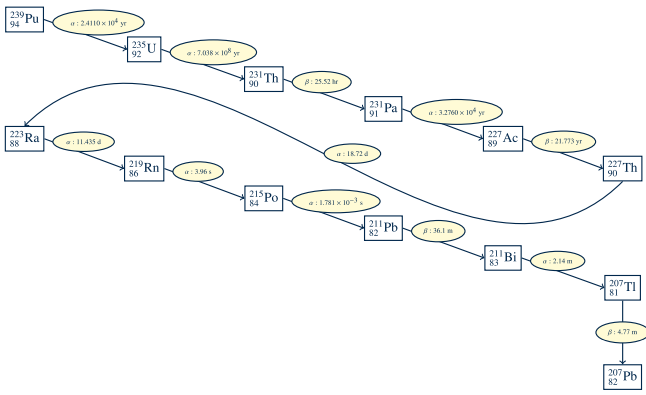
<BR><BR>
Your code should use the dictionary to print out<BR>
• All the nuclides that decay by alpha decay<BR>
• The activity of 1 gram of each nuclide that is a beta emitter.<BR>

In [13]:
import numpy as np

decayChain = {
  "239-Pu" : {
    "half-life" : 7.60837485e11,
    "decay_mode" : "alpha",
    "mass" : 239.0521634
  },
  "235-U" : {
    "half-life" : 2.22097645e16,
    "decay_mode" : "alpha",
    "mass" : 235.043930
  },
  "231-Th" : {
    "half-life" : 91872,
    "decay_mode" : "beta",
    "mass" : 231.036304
  },
  "231-Pa" : {
    "half-life" : 1.03380489e12,
    "decay_mode" : "alpha",
    "mass" : 231.035884
  },
  "227-Ac" : {
    "half-life" : 686633328,
    "decay_mode" : "beta",
    "mass" : 227.02775
  },
  "227-Th" : {
    "half-life" : 1617408,
    "decay_mode" : "alpha",
    "mass" : 227.027704
  },
  "223-Ra" : {
    "half-life" : 987984,
    "decay_mode" : "alpha",
    "mass" : 223.018502
  },
  "219-Rn" : {
    "half-life" : 3.69,
    "decay_mode" : "alpha",
    "mass" : 219.009480 
  },
  "215-Po" : {
    "half-life" : 1.781e-3,
    "decay_mode" : "alpha",
    "mass" : 214.999420
  },
  "211-Pb" : {
    "half-life" : 2166,
    "decay_mode" : "beta",
    "mass" : 210.9887315
  },
  "211-Bi" : {
    "half-life" : 128.4,
    "decay_mode" : "alpha",
    "mass" : 210.98727
  },
  "207-Tl" : {
    "half-life" : 286.2,
    "decay_mode" : "beta",
    "mass" : 207.982018
  },
  "207-Pb" : {
    "half-life" : "stable",
    "decay_mode" : "alpha",
    "mass" : 206.975897
  },
}
print("All the nuclides that decay by alpha decay:")
for nuclide in decayChain:
  if decayChain[nuclide]["decay_mode"] == "alpha":
    print(nuclide)

print(" ")
print("The activity of 1 gram of each nuclide that is a beta emitter:")
for nuclide in decayChain:
  if decayChain[nuclide]["decay_mode"] == "beta":
    half_life = decayChain[nuclide]["half-life"]
    mass_number = int(nuclide.split("-")[0])
    N_Avogadro = 6.02214076e23
    atoms_per_gram = N_Avogadro / mass_number
    decay_constant = np.log(2) / half_life
    activity = atoms_per_gram * decay_constant
    print(f"{nuclide}: {activity:.2e} bq")

All the nuclides that decay by alpha decay:
239-Pu
235-U
231-Pa
227-Th
223-Ra
219-Rn
215-Po
211-Bi
207-Pb
 
The activity of 1 gram of each nuclide that is a beta emitter:
231-Th: 1.97e+16 bq
227-Ac: 2.68e+12 bq
211-Pb: 9.13e+17 bq
207-Tl: 7.05e+18 bq


### **Problem 6.1**
Write an assert statement that guarantees a variable n is less than 100 and is positive.

In [15]:
n = 50
assert 0 < n < 100, "n must be positive and less than 100"

### **Problem 6.3**
Write a function called soft_equivalence that takes as input 3 parameters: a, b, and tol. The function should return True if the absolute difference between a and b is less than tol, and return False otherwise. The parameter tol should be an optional parameter with a default value of $10^−6$.

In [14]:
def soft_equivalence(a, b, tol=1e-6):
    """
    Check if two values are approximately equal within a tolerance.
    
    Args:
        a: First value
        b: Second value
        tol: Tolerance (default: 1e-6)
    
    Returns:
        True if |a - b| < tol, False otherwise
    """
    return abs(a - b) < tol


### **Problem 6.4**
Create a list of tests you would perform to test a function solve(A,b) that returns the solution to the linear system $Ax = b$. You do not need to write any code, just describe the tests, either in equations and/or words.

- Test that Int and Float values work
- Test different types entered together
- Test when A and b both = 0 -> should be infinite solutions
- Test when A = 0 and b != 0 -> should be no solutions
- Test when A is very large and b is very small or vice versa
- Test complex numbers (maybe?)
- solve(k*A, k*b) should give same x  as solve(A,b)
- solve(A,b) should satisfy Ax - b = 0 